<a href="https://colab.research.google.com/github/barbaradsiqueira/Trabalho-de-estat-stica/blob/main/trabalho_de_estatistica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
#=======================LIMPEZA DO AMBIENTE=====================================
#limpa objetos do workspace e previne conflitos
rm(list = ls())

#Evita notação cientifica e melhora a legibilidade numérica no console
options(scipen = 999, digits = 4)

#Fecha janelas graficas abertas em execuções anteriores
graphics.off()

#=======================PACOTES NECESSÁRIOS=====================================
#instalação caso necessário
if(!require("janitor")) install.packages("janitor")
if(!require("sidrar")) install.packages("sidrar")
if(!require("conflicted")) install.packages("conflicted")
if(!require("readr")) install.packages("readr")
if(!require("ipeadatar")) install.packages("ipeadatar")
if(!require("tidyr")) install.packages("tidyr")


#chamando bibliotecas
library(readr)
library(dplyr)
library(sidrar)
library(tidyverse)
library(conflicted)
library(janitor)
library(ipeadatar)
library(tidyr)
library(ipeadatar)

In [12]:
#=========================================================================
# 2.2 Coleta de Dados
#=========================================================================
# a) Cosntrução do Dataframe - Dados de Criminalidade
#VARIÁVEL: df_dados_de_criminalidade
#----------------------------
library(sidrar)

#recebe o link de download da tabela
url_csv <- "https://drive.google.com/uc?export=download&id=12_MRBwS1QP26HpwuVAJr4cb-gylc0m5d"

#recebe a leitura do arquivo
dados_de_criminalidade <- readr::read_delim(url_csv,
                                            delim = ",",
                                            col_names = TRUE,
                                            locale = locale(encoding = "UTF-8", decimal_mark = "."),
                                            col_types = cols(uf             = col_character(),
                                                             municipio      = col_character(),
                                                             cod_municipio  = col_integer(),
                                                             total_vitima   = col_integer(),
                                                             populacao_2022 = col_integer())
                                            ) %>%
  #arredondamento de casas decimais
  mutate(taxa_100mil = round(taxa_100mil, 2))


# Seleção do Estado
estado <- "SP"

df_dados_de_criminalidade <- dados_de_criminalidade %>%
dplyr::filter(uf == estado) %>%
# Garantir que o código seja tratado como texto para evitar perda de zeros à esquerda
mutate(cod_municipio = as.character(cod_municipio))

# Verificar se o filtro funcionou
print(paste("Total de Municípios no estado selecionado:", nrow(df_dados_de_criminalidade)))
head(df_dados_de_criminalidade)


#---------------------------
#b)Ulilizar o pacote SIDRAR - Dados do Produto Interno Bruto de 2023 para cada município
#VARIÁVEL: df_pib_per_capita
#---------------------------
#recupera os dados dos municipios de SP no SIDRAR
pib_tot_2023 <- get_sidra(api = "/t/5938/n6/all/v/37/p/last%201/d/v37%200")

#DEBUG
#pib_tot_2023

pib_tot_2023 <- pib_tot_2023 %>%
  clean_names() %>%
  select(cod_municipio = "municipio_codigo","municipio", "valor") %>%
  dplyr::filter(str_ends(municipio," - SP"))

pib_tot_2023

df_dados_de_criminalidade_limpo <- df_dados_de_criminalidade %>% clean_names()
names(df_dados_de_criminalidade_limpo)
names(pib_tot_2023)

pib_tot_2023

#integrando as tabelas
df_pib_per_capita <- pib_tot_2023 %>%
  left_join(df_dados_de_criminalidade_limpo %>% select(cod_municipio, populacao_2022), by = c("cod_municipio" = "cod_municipio")) %>%
  mutate(pib_per_capita = (valor * 1000) / populacao_2022, # 'valor' comes from pib_tot_2023
         pib_per_capita = round(pib_per_capita, 2)) %>%
  select(cod_municipio, pib_per_capita)


#DEBUG
head(df_pib_per_capita)



#---------------------------
#c) Quantidade de aglomerados urbanos por municipio
#VARIÁVEL: df_aglomerados_por_municipio
#---------------------------
#RECEBE O RETORNO DA API
url_aglomerados <- get_sidra(api = "/t/9883/n6/all/v/all/p/all")
#IDENTIFICA DO TIPO DA VARIAVEL
class(url_aglomerados)

#SANITIZAÇÃO DE NOMES DE COLUNAS
df_aglomerados_limpo <- url_aglomerados %>% clean_names()

#DEBUG
head(df_aglomerados_limpo)

#FORMATAÇÃO E SELEÇÃO DO DF
df_aglomerados <- df_aglomerados_limpo %>%
  #SELEÇÃO DAS COLUNAS DE INTERESSE ALTERANDO NOME DE COLUNA,
  select(codigo ="municipio_codigo","municipio", "valor") %>%
  #FILTRO DE DADOS(*-SP),
  dplyr::filter(str_ends(municipio, " - SP"))

#DEBUG
# head(df_aglomerados)
# list.files()

#CRIANDO DF_FINAL COM TODOS OS MUNICIPIOS E VALOR "0" ATRIBUIDO AO MUNICIPIO EM QUE NÃO HA AGLOMERADO
df_aglomerados_por_municipio <- df_dados_de_criminalidade %>%
  left_join(df_aglomerados, by = c("cod_municipio" = "codigo"))%>%
  select("cod_municipio",municipio = "municipio.x","uf",qnt_aglomerados = "valor") %>%
  #ALTERA OS RESULTADOS NA -> 0
  replace_na(list(qnt_aglomerados = 0))
  #ALTERNATIVA: DEVOLVE O MESMO RESULTADO
  # mutate(qnt_aglomerados = coalesce(as.numeric(qnt_aglomerados), 0))

#DEBUG
# head(df_aglomerados_por_municipio)
# print(df_aglomerados_por_municipio, n=600)



#---------------------------
#d) Pessoas alfabetizadas por municipio, criar coluna com taxa de analfabetismo municipal
#VARIÁVEL: df_analfabetismo_por_municipio
#---------------------------
#RECEBE A URL
url_analfabetismo <- get_sidra(api = "/t/9543/n6/all/v/all/p/all/c2/6794/c86/95251/c287/100362/d/v2513%202")
#TRATAMENTO E SELEÇÃO DA TABELA
df_analfabetismo_por_municipio <-url_analfabetismo %>%
  clean_names() %>%
  select(cod_municipio = "municipio_codigo", "municipio","valor", medida = "unidade_de_medida") %>%
  dplyr::filter(str_ends(municipio, " - SP")) %>%
  #CALCULO DO ANALFATETISMO POR MUNICIPIO
  mutate(valor = (100 - valor), valor = round(valor, 2))

#DEBUG
#print(analfabetismo)



#---------------------------
#e)Percentual da população jovem (entre 15 e 29 anos)nos municípios
#VARIÁVEL: df_populacao_jovem_por_municipio
#---------------------------
#RECEBENDO DADOS DA API
populacao_jovem <- get_sidra(api = "/t/9514/n6/all/v/allxp/p/all/c2/6794/c287/93086,93087,93088/c286/113635")

#TRATANDO TABELA
df_populacao_15_29 <- populacao_jovem %>%
  clean_names() %>%
  select(cod_municipio = "municipio_codigo","municipio", "idade", "valor" ) %>%
  dplyr::filter(str_ends(municipio, " - SP")) %>%
  group_by(cod_municipio, municipio) %>%
  summarise(pop_jovem = sum(valor, na.rm = TRUE), .groups = "drop")

#DEBUG
# df_populacao_15_29
names(df_populacao_15_29)
names(df_dados_de_criminalidade)

#UNINDO TABELAS/CALCULANDO VALORES PARA CRIAÇÃO DA COLUNA POLULAÇÃO JOVEM POR MUNICIPIO
df_populacao_jovem_por_municipio <- df_populacao_15_29 %>%
  left_join(df_dados_de_criminalidade, by =c("cod_municipio" = "cod_municipio")) %>%
    mutate( pop_jovem_municipio = (pop_jovem * 100) / populacao_2022, medida = "%", pop_jovem_municipio = round(pop_jovem_municipio, 2)) %>%
    select("cod_municipio", municipio = "municipio.y", "pop_jovem_municipio", "medida")


df_populacao_jovem_por_municipio

#---------------------------
#f)Familias beneficiadas pelo Bolsa Familia em dezembro de 2024
# VARIÁVEL: df_pbf_por_municipio
#---------------------------

#ARQUIVO COMPLETO
pbf_bruto <- ipeadata("FAM_PBF")

# print(pbf_bruto, n = 90698)
names(pbf_bruto)
#FILTRO DE DATA E MUNICIPIO
df_pbf_sp <- pbf_bruto %>%
  # Garante que o código seja tratado como texto
  mutate(code = as.character(code)) %>%

  # FILTRO DE SP: Mantém apenas códigos que começam com "35"
  # E filtra a data de dezembro de 2024 (jan/2025 no sistema)
  dplyr::filter(
    str_starts(tcode, "35"),
    date == as.Date("2025-01-01")
  ) %>%

  # Limpeza final
  rename(cod_municipio = code, total_familias_pbf = value, codigo_territorio = tcode) %>%
  select(cod_municipio, date, total_familias_pbf, codigo_territorio) %>%
  mutate(codigo_territorio = as.character(codigo_territorio))

# names(df_pbf_sp)
# print(df_pbf_sp)

# names(df_dados_de_criminalidade_limpo)
# names(df_pbf_sp)

df_pbf_por_municipio <- df_dados_de_criminalidade_limpo %>%
  left_join(df_pbf_sp, by = c("cod_municipio" = "codigo_territorio")) %>%
  mutate(
    pbf_100_mil = (total_familias_pbf / populacao_2022) * 100000,
    pbf_100_mil = round(pbf_100_mil, 2)) %>%
  select("cod_municipio", "municipio", "date", "total_familias_pbf", pbf_100_mil = "pbf_100_mil")

df_pbf_por_municipio


#RESUMO DA COLETA DE DADOS
print("Data Frame - Coleta de Datos - a)")
head(df_dados_de_criminalidade)
#------------------------------------------
print("Data Frame - Coleta de Datos - b)")
head(df_pib_per_capita)
#------------------------------------------
print("Data Frame - Coleta de Datos - c)")
head(df_aglomerados_por_municipio)
#------------------------------------------
print("Data Frame - Coleta de Datos - d)")
head(df_analfabetismo_por_municipio)
#------------------------------------------
print("Data Frame - Coleta de Datos - e)")
head(df_populacao_jovem_por_municipio)
#------------------------------------------
print("Data Frame - Coleta de Datos - f)")
head(df_pbf_por_municipio)
#------------------------------------------

[1] "Total de Municípios no estado selecionado: 645"


uf,municipio,cod_municipio,total_vitima,populacao_2022,taxa_100mil
<chr>,<chr>,<chr>,<int>,<int>,<dbl>
SP,ADAMANTINA,3500105,54,34687,14.15
SP,ADOLFO,3500204,15,4351,31.34
SP,AGUAI,3500303,104,32072,29.48
SP,AGUDOS,3500709,126,37680,30.40
SP,ALAMBARI,3500758,15,6141,22.21
SP,ALFREDO MARCONDES,3500808,12,4445,24.54


All others arguments are desconsidered when 'api' is informed



cod_municipio,municipio,valor
<chr>,<chr>,<dbl>
3500105,Adamantina - SP,1705895
3500204,Adolfo - SP,215283
3500303,Aguaí - SP,1773843
3500402,Águas da Prata - SP,272359
3500501,Águas de Lindóia - SP,801115
3500550,Águas de Santa Bárbara - SP,375562
3500600,Águas de São Pedro - SP,185390
3500709,Agudos - SP,3415809
3500758,Alambari - SP,160252


[1] "uf"             "municipio"      "cod_municipio"  "total_vitima"  
[5] "populacao_2022" "taxa_100mil"

...

,cod_municipio,municipio,valor,medida
,<chr>,<chr>,<dbl>,<chr>
1,3500105,Adamantina - SP,3.51,%
2,3500204,Adolfo - SP,6.78,%
3,3500303,Aguaí - SP,4.97,%
4,3500402,Águas da Prata - SP,3.15,%
5,3500501,Águas de Lindóia - SP,3.59,%
6,3500550,Águas de Santa Bárbara - SP,4.36,%


[1] "Data Frame - Coleta de Datos - e)"


cod_municipio,municipio,pop_jovem_municipio,medida
<chr>,<chr>,<dbl>,<chr>
3500105,ADAMANTINA,18.29,%
3500204,ADOLFO,18.69,%
3500303,AGUAI,21.67,%
3500402,AGUAS DA PRATA,15.90,%
3500501,AGUAS DE LINDOIA,18.16,%
3500550,AGUAS DE SANTA BARBARA,18.66,%


[1] "Data Frame - Coleta de Datos - f)"


cod_municipio,municipio,date,total_familias_pbf,pbf_100_mil
<chr>,<chr>,<date>,<dbl>,<dbl>
3500105,ADAMANTINA,2025-01-01,697,2009
3500204,ADOLFO,2025-01-01,162,3723
3500303,AGUAI,2025-01-01,1955,6096
3500709,AGUDOS,2025-01-01,1410,3742
3500758,ALAMBARI,2025-01-01,220,3582
3500808,ALFREDO MARCONDES,2025-01-01,244,5489


[conflicted] Removing existing preference.
[conflicted] Will prefer dplyr::filter over any other package.



 (i) ATESTADO DE FORMATAÇÃO: VARIÁVEIS QUANTITATIVAS VALIDADAS COMO NUMÉRICAS

 a) ESTATÍSTICA DESCRITIVA DAS VARIÁVEIS DO MODELO:


|  Variavel   | Minimo |  Q1   | Mediana | Media |  Q3   | Maximo | Desvio_Padrao | CV_Porcentagem |
|:-----------:|:------:|:-----:|:-------:|:-----:|:-----:|:------:|:-------------:|:--------------:|
| perc_jovem  | 14.35  | 19.09 |  20.24  | 20.3  | 21.45 | 37.39  |     2.219     |     10.93      |
|   pib_pc    | 13549  | 32905 |  46614  | 57736 | 64315 | 606741 |     48643     |     84.25      |
| qtde_favela |   0    |   0   |    0    | 4.842 |   0   |  1359  |     54.95     |      1135      |
|   tx_HOM    |   0    | 21.61 |  27.91  | 32.05 | 38.63 | 149.4  |     16.38     |     51.11      |
| tx_analfab  |  1.16  |  3.7  |    5    | 5.147 | 6.28  | 12.23  |     1.839     |     35.72      |
|  tx_bolsa   | 946.4  | 3552  |  4827   | 5375  | 6698  | 18285  |     2495      |     46.41      |


 b) (ii) AVALIÇÃO DESCRITIVA DE OUTLIERS NOS PREDITORES 

`geom_smooth()` using formula = 'y ~ x'



 f) TESTES DE DIAGNÓSTICO DOS PRESSUPOSTOS DA REGRESSÃO LINEAR CLÁSSICA:
[1] Verificação de Multicolinearidade via Fator de Inflação da Variância (VIF):


|  Variavel   |  VIF  |
|:-----------:|:-----:|
|   pib_pc    | 1.083 |
| qtde_favela | 1.016 |
| tx_analfab  | 1.374 |
| perc_jovem  | 1.115 |
|  tx_bolsa   | 1.374 |


[2] Tabela unificada de validação das premissas sobre os erros de estimação:


|      Pressuposto Avaliado      | Teste Estatístico | Estatística | p-valor |        Decisão Estatística         |
|:------------------------------:|:-----------------:|:-----------:|:-------:|:----------------------------------:|
|       Homocedasticidade        |   Breusch-Pagan   |    35.57    |    0    |    Rejeita H0: Heterocedásticos    |
| Independência (Autocorrelação) |   Durbin-Watson   |    1.971    | 0.3513  | Mantém H0: Não Autocorrelacionados |
|    Normalidade dos Resíduos    | Anderson-Darling  |    14.26    |    0    |      Rejeita H0: Não-Normais       |


 g) EQUAÇÃO D

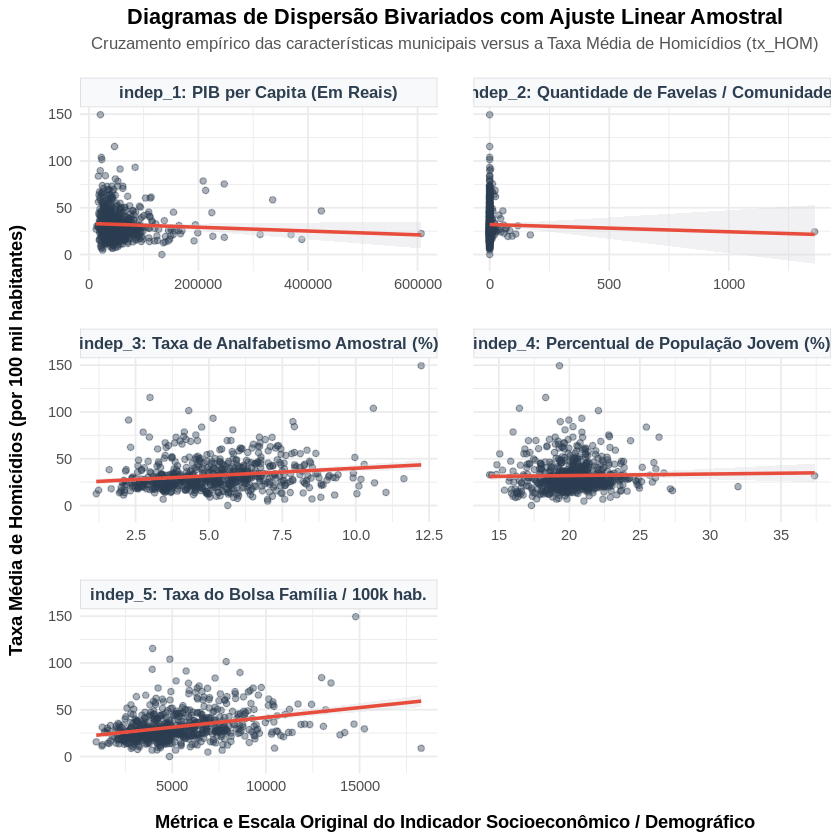

In [42]:
# ==============================================================================
# ITEM 2.3. CONSTRUÇÃO DO MODELO: MUNICÍPIOS DE SÃO PAULO
# ==============================================================================

# --- CARREGAMENTO DE BIBLIOTECAS SUPORTE ---
library(tidyverse)
library(nortest)
library(lmtest)
library(car)
library(lm.beta)
library(broom)

if(!require(pander)) install.packages("pander")
library(pander)

if(data.class(conflicts_prefer) == "function") {
  conflicts_prefer(dplyr::filter)
}

panderOptions("table.split.table", Inf)
panderOptions("table.style", "rmarkdown")

# Consolidação segura das tabelas provenientes do bloco 2.2
dados_sp <- df_dados_de_criminalidade %>%
  select(cod_municipio, municipio, taxa_homicidios = taxa_100mil) %>%
  left_join(df_pib_per_capita %>% select(cod_municipio, pib_per_capita), by = "cod_municipio") %>%
  left_join(df_aglomerados_por_municipio %>% select(cod_municipio, aglomerados = qnt_aglomerados), by = "cod_municipio") %>%
  left_join(df_analfabetismo_por_municipio %>% select(cod_municipio, taxa_analfabetismo = valor), by = "cod_municipio") %>%
  left_join(df_populacao_jovem_por_municipio %>% select(cod_municipio, percentual_jovens = pop_jovem_municipio), by = "cod_municipio") %>%
  left_join(df_pbf_por_municipio %>% select(cod_municipio, taxa_bolsa = pbf_100_mil), by = "cod_municipio")


# ------------------------------------------------------------------------------
# Inserção de todas as variáveis em um novo data frame
# ------------------------------------------------------------------------------
df_modelo <- dados_sp %>%
  select(
    municipio,
    tx_HOM      = any_of(c("taxa_homicidios")),
    pib_pc      = any_of(c("pib_per_capita")),
    qtde_favela = any_of(c("aglomerados")),
    tx_analfab  = any_of(c("taxa_analfabetismo")),
    perc_jovem  = any_of(c("percentual_jovens")),
    tx_bolsa    = any_of(c("taxa_bolsa"))
  )

# ------------------------------------------------------------------------------
# Atestar que os dados numéricos estejam formatados como número
# ------------------------------------------------------------------------------
df_modelo <- df_modelo %>%
  mutate(qtde_favela = if_else(is.na(qtde_favela), 0, qtde_favela)) %>%
  mutate(across(c(tx_HOM, pib_pc, qtde_favela, tx_analfab, perc_jovem, tx_bolsa), as.numeric)) %>%
  drop_na()

cat("\n========================================================================\n")
cat(" (i) ATESTADO DE FORMATAÇÃO: VARIÁVEIS QUANTITATIVAS VALIDADAS COMO NUMÉRICAS\n")
cat("========================================================================\n\n")


# ------------------------------------------------------------------------------
# a) Realização de estatística descritiva de cada uma dessas variáveis,
# incluindo o resumo dos 5 números, a média e o desvio-padrão e o coeficiente de variação.
# ------------------------------------------------------------------------------
cv_func <- function(x) (sd(x, na.rm = TRUE) / mean(x, na.rm = TRUE)) * 100

tabela_descritiva <- df_modelo %>%
  select(-municipio) %>%
  pivot_longer(cols = everything(), names_to = "Variavel", values_to = "Valor") %>%
  group_by(Variavel) %>%
  summarise(
    Minimo         = min(Valor, na.rm = TRUE),
    Q1             = quantile(Valor, 0.25, na.rm = TRUE),
    Mediana        = median(Valor, na.rm = TRUE),
    Media          = mean(Valor, na.rm = TRUE),
    Q3             = quantile(Valor, 0.75, na.rm = TRUE),
    Maximo         = max(Valor, na.rm = TRUE),
    Desvio_Padrao  = sd(Valor, na.rm = TRUE),
    CV_Porcentagem = cv_func(Valor)
  )

cat("========================================================================\n")
cat(" a) ESTATÍSTICA DESCRITIVA DAS VARIÁVEIS DO MODELO:\n")
cat("========================================================================\n")
pander(as.data.frame(tabela_descritiva))
cat("\n")


# ------------------------------------------------------------------------------
# b) Criação de variáveis estandardizadas (Z_score) para cada uma das variáveis
# quantitativas e avaliação pelo critério de afastamento em desvios-padrão se existem outliers em alguma variável
# ------------------------------------------------------------------------------
df_zscore_preditores <- df_modelo %>%
  select(municipio, pib_pc, qtde_favela, tx_analfab, perc_jovem, tx_bolsa) %>%
  mutate(across(c(pib_pc, qtde_favela, tx_analfab, perc_jovem, tx_bolsa), list(z = ~as.numeric(scale(.))), .names = "{col}_z"))

outliers_zscore <- df_zscore_preditores %>%
  select(municipio, ends_with("_z")) %>%
  pivot_longer(cols = -municipio, names_to = "Variavel_Z", values_to = "Z_Score") %>%
  filter(abs(Z_Score) > 3)

cat("========================================================================\n")
cat(" b) (ii) AVALIÇÃO DESCRITIVA DE OUTLIERS NOS PREDITORES (|Z| > 3):\n")
cat("========================================================================\n")
if(nrow(outliers_zscore) > 0) {
  pander(as.data.frame(outliers_zscore))
} else {
  cat("Nenhum outlier descritivo detectado nos preditores pelo critério de desvios-padrão.\n")
}
cat("\n")


# ------------------------------------------------------------------------------
# c) Testes de hipótese formais robustos para identificar a NORMALIDADE das variáveis, bem como a presença de OUTLIERS.
# ------------------------------------------------------------------------------
modelo_1 <- lm(tx_HOM ~ pib_pc + qtde_favela + tx_analfab + perc_jovem + tx_bolsa, data = df_modelo)

teste_ad_residuos <- ad.test(residuals(modelo_1))
tabela_normalidade_formal <- tibble(
  `Objeto de Análise` = "Resíduos do Modelo Estimado (u_i)",
  `Teste Estatístico` = "Anderson-Darling",
  `Estatística A`     = round(as.numeric(teste_ad_residuos$statistic), 4),
  `p-valor`           = round(teste_ad_residuos$p.value, 5),
  `Resultado H0`      = if_else(teste_ad_residuos$p.value > 0.05, "Mantém H0: Distribuição Normal", "Rejeita H0: Distribuição Não-Normal")
)

cat("========================================================================\n")
cat(" c) TESTES DE HIPÓTESE FORMAIS ROBUSTOS (NORMALIDADE E OUTLIERS DO MODELO):\n")
cat("========================================================================\n")
cat("\n[1] Teste Formal de Normalidade dos Resíduos Estocásticos:\n")
pander(as.data.frame(tabela_normalidade_formal))

cat("\n[2] Teste Formal de Hipótese para Outliers nos Resíduos (Critério Estatístico de Bonferroni):\n")
print(outlierTest(modelo_1))
cat("\n")


# ------------------------------------------------------------------------------
# d) Geração de matriz de correlação entre a variável dependente e as variáveis independentes e interpretação do valor obtido.
# ------------------------------------------------------------------------------
cat("========================================================================\n")
cat(" d) MATRIZ DE CORRELAÇÃO DE PEARSON ENVOLVENDO AS VARIÁVEIS DA REGRESSÃO:\n")
cat("========================================================================\n")
pander(cor(df_modelo %>% select(-municipio), method = "pearson"))
cat("\n")


# ------------------------------------------------------------------------------
# e) Apresentação de gráfico de dispersão que apoie essa análise.
# ------------------------------------------------------------------------------
cat("========================================================================\n")
cat(" e) APRESENTAÇÃO DO GRÁFICO DE DISPERSÃO MULTIFACETADO ESTILIZADO:\n")
cat("========================================================================\n")
print(
  df_modelo %>%
    pivot_longer(cols = c(pib_pc, qtde_favela, tx_analfab, perc_jovem, tx_bolsa), names_to = "Independente", values_to = "Valor") %>%
    mutate(Independente_Label = case_when(
      Independente == "pib_pc"      ~ "indep_1: PIB per Capita (Em Reais)",
      Independente == "qtde_favela" ~ "indep_2: Quantidade de Favelas / Comunidades",
      Independente == "tx_analfab"  ~ "indep_3: Taxa de Analfabetismo Amostral (%)",
      Independente == "perc_jovem"  ~ "indep_4: Percentual de População Jovem (%)",
      Independente == "tx_bolsa"    ~ "indep_5: Taxa do Bolsa Família / 100k hab."
    )) %>%
    ggplot(aes(x = Valor, y = tx_HOM)) +
    geom_point(alpha = 0.4, color = "#2c3e50", size = 1.5) +
    geom_smooth(method = "lm", color = "#e74c3c", fill = "#dcdde1", se = TRUE, size = 1) +
    facet_wrap(~Independente_Label, scales = "free_x", ncol = 2) +
    theme_minimal(base_size = 11) +
    theme(
      plot.title = element_text(face = "bold", size = 13, hjust = 0.5, margin = margin(b = 5)),
      plot.subtitle = element_text(size = 10, color = "#555555", hjust = 0.5, margin = margin(b = 15)),
      axis.title.x = element_text(face = "bold", size = 11, margin = margin(t = 12)),
      axis.title.y = element_text(face = "bold", size = 11, margin = margin(r = 12)),
      strip.text = element_text(face = "bold", size = 10, color = "#2c3e50"),
      strip.background = element_rect(fill = "#f8f9fa", color = "#dcdde1"),
      panel.spacing = unit(1.5, "lines")
    ) +
    labs(
      title = "Diagramas de Dispersão Bivariados com Ajuste Linear Amostral",
      subtitle = "Cruzamento empírico das características municipais versus a Taxa Média de Homicídios (tx_HOM)",
      x = "Métrica e Escala Original do Indicador Socioeconômico / Demográfico",
      y = "Taxa Média de Homicídios (por 100 mil habitantes)"
    )
)
cat("\n")


# ------------------------------------------------------------------------------
# f) Realização de testes dos pressupostos de uma regressão linear múltipla e analise os resultados obtidos.
# ------------------------------------------------------------------------------
cat("========================================================================\n")
cat(" f) TESTES DE DIAGNÓSTICO DOS PRESSUPOSTOS DA REGRESSÃO LINEAR CLÁSSICA:\n")
cat("========================================================================\n")

cat("[1] Verificação de Multicolinearidade via Fator de Inflação da Variância (VIF):\n")
vif_valores <- vif(modelo_1)
pander(data.frame(Variavel = names(vif_valores), VIF = as.numeric(vif_valores)))

teste_bp     <- bptest(modelo_1)
teste_dw     <- dwtest(modelo_1)

tabela_pressupostos_H <- tibble(
  `Pressuposto Avaliado` = c("Homocedasticidade", "Independência (Autocorrelação)", "Normalidade dos Resíduos"),
  `Teste Estatístico`    = c("Breusch-Pagan", "Durbin-Watson", "Anderson-Darling"),
  `Estatística`          = c(round(as.numeric(teste_bp$statistic), 4), round(as.numeric(teste_dw$statistic), 4), round(as.numeric(teste_ad_residuos$statistic), 4)),
  `p-valor`              = c(round(teste_bp$p.value, 5), round(teste_dw$p.value, 5), round(teste_ad_residuos$p.value, 5)),
  `Decisão Estatística`  = c(
    if_else(teste_bp$p.value > 0.05, "Mantém H0: Homocedásticos", "Rejeita H0: Heterocedásticos"),
    if_else(teste_dw$p.value > 0.05, "Mantém H0: Não Autocorrelacionados", "Rejeita H0: Autocorrelacionados"),
    if_else(teste_ad_residuos$p.value > 0.05, "Mantém H0: Resíduos Normais", "Rejeita H0: Não-Normais")
  )
)
cat("\n[2] Tabela unificada de validação das premissas sobre os erros de estimação:\n")
pander(as.data.frame(tabela_pressupostos_H))
cat("\n")


# ------------------------------------------------------------------------------
# g) Estimar a regressão linear múltipla sugerida pela modelagem
# ------------------------------------------------------------------------------
modelo_1_padrao   <- lm.beta(modelo_1)
sum_m1            <- summary(modelo_1)
ic_95             <- confint(modelo_1, level = 0.95)
coef_padronizados <- coef(modelo_1_padrao)
co                <- coef(modelo_1)

cat("========================================================================\n")
cat(" g) EQUAÇÃO DA FUNÇÃO DE REGRESSÃO AMOSTRAL ESTIMADA PARA SÃO PAULO:\n")
cat("========================================================================\n")
cat(sprintf("tx_HOM = %.5f + (%.5f)*pib_pc + (%.5f)*qtde_favela + (%.5f)*tx_analfab + (%.5f)*perc_jovem + (%.5f)*tx_bolsa\n",
            co["(Intercept)"], co["pib_pc"], co["qtde_favela"], co["tx_analfab"], co["perc_jovem"], co["tx_bolsa"]))
cat("\n")


# ------------------------------------------------------------------------------
# h) Criação de uma tabela com dados de qualidade da regressão,
# dos resultados obtidos desta modelagem
# ------------------------------------------------------------------------------
corpo_tabela_h <- tidy(modelo_1) %>%
  mutate(
    Variavel = case_when(
      term == "(Intercept)" ~ "Intercepto (constante)",
      term == "pib_pc"      ~ "indep_1",
      term == "qtde_favela" ~ "indep_2",
      term == "tx_analfab"  ~ "indep_3",
      term == "perc_jovem"  ~ "indep_4",
      term == "tx_bolsa"    ~ "indep_5"
    ),
    Coeficiente          = as.character(round(estimate, 5)),
    `Erro Padrao`        = as.character(round(std.error, 5)),
    `Coef. Padronizados` = case_when(term == "(Intercept)" ~ "   -   ", TRUE ~ as.character(round(coef_padronizados[term], 5))),
    `Estatística t`      = as.character(round(statistic, 5)),
    `p-valor (sig.)`     = as.character(format.pval(p.value, digits = 4)),
    `IC95 Min`           = as.character(round(ic_95[term, 1], 5)),
    `IC95 Max`           = as.character(round(ic_95[term, 2], 5))
  ) %>%
  select(Variavel, Coeficiente, `Erro Padrao`, `Coef. Padronizados`, `Estatística t`, `p-valor (sig.)`, `IC95 Min`, `IC95 Max`)

linha_rodape_barema <- tibble(
  Variavel             = paste0("n = ", nobs(modelo_1)),
  Coeficiente          = paste0("R2 = ", round(sum_m1$r.squared, 4)),
  `Erro Padrao`        = paste0("R2 ajustado = ", round(sum_m1$adj.r.squared, 4)),
  `Coef. Padronizados` = paste0("Estat. F = ", round(sum_m1$fstatistic[1], 2)),
  `Estatística t`      = paste0("p global = ", format.pval(pf(sum_m1$fstatistic[1], sum_m1$fstatistic[2], sum_m1$fstatistic[3], lower.tail = FALSE), digits = 4)),
  `p-valor (sig.)`     = paste0("AIC = ", round(AIC(modelo_1), 1)),
  `IC95 Min`           = paste0("BIC = ", round(BIC(modelo_1), 1)),
  `IC95 Max`           = paste0("Erro padrao residual = ", round(sum_m1$sigma, 4))
)

tabela_final_barema <- bind_rows(corpo_tabela_h, linha_rodape_barema)

cat("========================================================================================================================\n")
cat(" h) DOS RESULTADOS OBTIDOS DESTA MODELAGEM, CRIE UMA TABELA COMPATÍVEL COM O GRID EXIGIDO NO BAREMA:\n")
cat("========================================================================================================================\n")
pander(as.data.frame(tabela_final_barema))
cat("========================================================================================================================\n\n")